#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
import os
csv_files = [
    f for f in os.listdir('/content')
    if f.endswith('.csv')
]
print(csv_files)

['Mall_Customers.csv']


#Loading the dataset

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#Checking the shape and column name

In [ ]:
df.shape
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

#Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


#Checking the missing values

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


#Selecting the features

In [ ]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

#Visualization

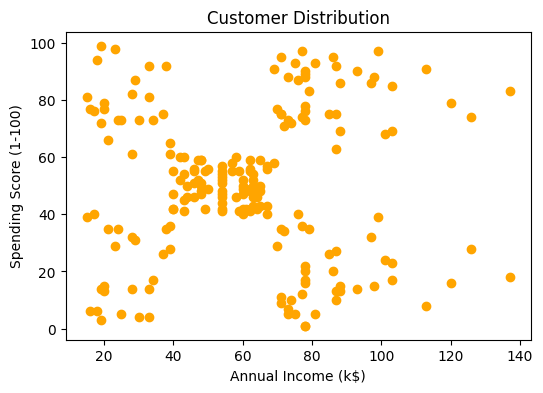

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], color = "orange")
plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.savefig("Customer_Distribution.png")
plt.show()

#Finding the best number of clusters(Elbow Method)

In [ ]:
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, random_state = 42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

#Plotting the Elbow method

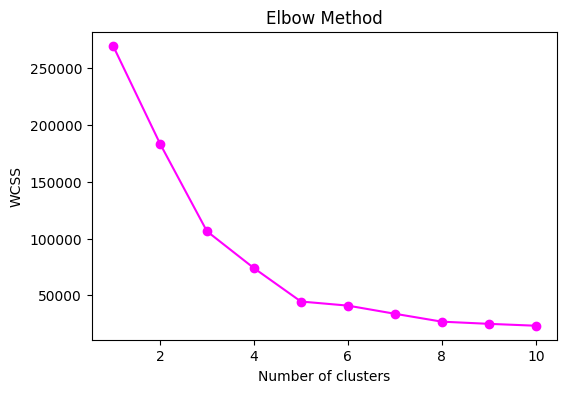

In [ ]:
plt.figure(figsize = (6,4))
plt.plot(range(1,11), wcss, marker = 'o', color = "Magenta")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.savefig("Elbow_Method.png")
plt.show()

#Applying kmeans

In [ ]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
y_kmeans = kmeans.fit_predict(x)
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


#Plotting the clusters

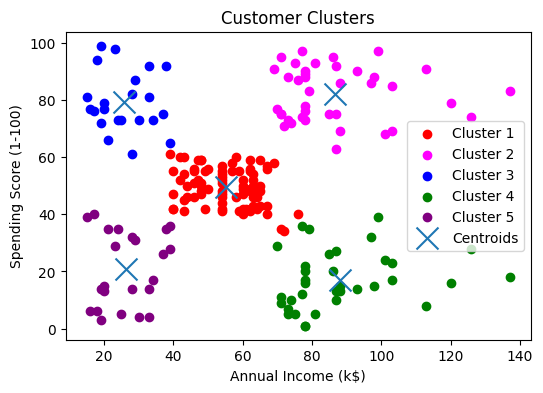

In [ ]:
plt.figure(figsize = (6,4))
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0,1], label = 'Cluster 1', color = "red")
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1,1], label = 'Cluster 2', color = "magenta")
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2,1], label = 'Cluster 3', color = "blue")
plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3,1], label = 'Cluster 4', color = "green")
plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4,1], label = 'Cluster 5', color = "purple")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 250, marker = 'x', label = 'Centroids')
plt.title("Customer Clusters")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.savefig("Customer_Clusters.png")
plt.show()

#Adding clusters labels to the Dataset

In [ ]:
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#Saving the clustered Dataset

In [ ]:
df.to_csv("Mall_Customers_Clustered.csv", index = False)
print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!
